# 🧬 Bio-JEPA — Pipeline Complet
**Apprentissage de représentations sémantiques pour le repositionnement de molécules**

---

## ⚙️ Avant de commencer
1. `Runtime → Change runtime type → A100 GPU`
2. Exécuter les cellules **dans l'ordre**
3. Les checkpoints sont sauvegardés sur **Google Drive** automatiquement

---

## 📋 Plan
| Étape | Description | Durée estimée |
|---|---|---|
| 0 | Vérification GPU | 1 min |
| 1 | Montage Google Drive | 1 min |
| 2 | Installation des dépendances | 3 min |
| 3 | Clone du repo GitHub | 1 min |
| 4 | Pré-entraînement ZINC250k (Phase 1) | ~30 min |
| 5 | Sauvegarde checkpoint Phase 1 | 1 min |
| 6 | Few-shot eval — Transfert ZINC→ChEMBL (Phase 2a) | ~30 min |
| 7 | Few-shot eval — In-domain (Phase 2b) | ~30 min |
| 8 | Sauvegarde finale + Visualisation | 2 min |

---
## Étape 0 — Vérification du GPU

In [1]:
import torch
!nvidia-smi
print(f'\n✓ PyTorch : {torch.__version__}')
print(f'✓ CUDA disponible : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'✓ GPU : {torch.cuda.get_device_name(0)}')
    print(f'✓ VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Fri Mar  6 10:30:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

---
## Étape 1 — Montage Google Drive

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_SAVE_PATH = '/content/drive/MyDrive/Bio-JEPA-checkpoints'
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

print(f'✓ Google Drive monté')
print(f'✓ Dossier de sauvegarde : {DRIVE_SAVE_PATH}')

Mounted at /content/drive
✓ Google Drive monté
✓ Dossier de sauvegarde : /content/drive/MyDrive/Bio-JEPA-checkpoints


---
## Étape 2 — Installation des dépendances

In [3]:
!pip install torch_geometric rdkit pandas numpy scikit-learn tqdm requests pyyaml chembl-webresource-client -q
print('✓ Toutes les dépendances installées')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.4 MB/s eta 0:00:00
✓ Toutes les dépendances installées


---
## Étape 3 — Clone du repo GitHub

In [4]:
!git clone https://github.com/7Nayy/Bio-JEPA.git /content/Bio-JEPA
import os
os.chdir('/content/Bio-JEPA')
print(f'✓ Dossier courant : {os.getcwd()}')
!ls -la

Cloning into '/content/Bio-JEPA'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 75 (delta 4), reused 13 (delta 3), pack-reused 54 (from 2)
Receiving objects: 100% (75/75), 46.99 MiB | 16.99 MiB/s, done.
Resolving deltas: 100% (7/7), done.
✓ Dossier courant : /content/Bio-JEPA
total 752
drwxr-xr-x 9 root root   4096 Mar  6 10:31 .
drwxr-xr-x 1 root root   4096 Mar  6 10:31 ..
-rw-r--r-- 1 root root  22223 Mar  6 10:31 baseline.py
drwxr-xr-x 2 root root   4096 Mar  6 10:31 checkpoints
drwxr-xr-x 2 root root   4096 Mar  6 10:31 configs
drwxr-xr-x 4 root root   4096 Mar  6 10:31 data
drwxr-xr-x 3 root root   4096 Mar  6 10:31 evaluation
-rw-r--r-- 1 root root  33999 Mar  6 10:31 few_shot_eval.py
drwxr-xr-x 8 root root   4096 Mar  6 10:31 .git
drwxr-xr-x 3 root root   4096 Mar  6 10:31 models
-rw-r--r-- 1 root root   7792 Mar  6 10:31 pretrain.py
-rw-r--r-- 1 root root   1202 Mar  6 10:31

---
## Étape 4 — Phase 1 : Pré-entraînement sur ZINC250k

> **Objectif** : Apprendre une représentation générale des molécules sans aucun label  
> **Durée estimée** : ~30 min sur A100  
> ⚠️ Ne pas interrompre cette cellule

In [5]:
!python pretrain.py --config configs/pretrain_zinc.yaml

  Bio-JEPA — Pré-entraînement sur ZINC250k
  Protocole de transfert learning (Phase 1 / 2)

  Après ce script, lancez :
    python few_shot_eval.py \
        --checkpoint checkpoints/zinc_pretrained.pt \
        --target CHEMBL251 \
        --save-json results/few_shot_transfer.json

[Données] Chargement de ZINC250k...
  (Téléchargement automatique au premier appel, ~4 Mo)
[ZINC] Téléchargement de ZINC250k depuis GitHub...
  URL  : https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/models/zinc_properties/250k_rndm_zinc_drugs_clean_3.csv
  Dest : data/zinc/raw/250k_rndm_zinc_drugs_clean_3.csv
  ✓ Téléchargement réussi (22.6 Mo)
Processing...
[ZINC] 249,455 SMILES lus → conversion en graphes...
  50,000/249,455 traités...
  100,000/249,455 traités...
  150,000/249,455 traités...
  200,000/249,455 traités...
[ZINC] Conversion terminée : 249,455 graphes valides │ 0 SMILES invalides ignorés (0.0%)
[ZINC] Graphes mis en cache → data/zinc/processed/data.pt
Done!

  ZINC 

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Étape 5 — Sauvegarde checkpoint Phase 1
> ⚠️ Exécuter immédiatement après l'étape 4

In [7]:
import shutil, os

checkpoint_path = 'checkpoints/zinc_pretrained.pt'
assert os.path.exists(checkpoint_path), 'Checkpoint introuvable — vérifier étape 4'

shutil.copy(checkpoint_path, f'{DRIVE_SAVE_PATH}/zinc_pretrained.pt')
size_mb = os.path.getsize(f'{DRIVE_SAVE_PATH}/zinc_pretrained.pt') / 1e6
print(f'✓ Checkpoint sauvegardé sur Drive ({size_mb:.1f} MB)')

✓ Checkpoint sauvegardé sur Drive (13.0 MB)


---
## Étape 6 — Phase 2a : Few-shot — Transfert ZINC → ChEMBL251

> **Objectif** : Tester si les embeddings ZINC transfèrent sur ChEMBL251 avec peu de labels  
> **Durée estimée** : ~30 min sur A100

In [8]:
!python few_shot_eval.py \
    --checkpoint checkpoints/zinc_pretrained.pt \
    --target CHEMBL251 \
    --n-values 10,50,100,200,500,1000 \
    --n-runs 5 \
    --save-json results/few_shot_transfer.json

  Évaluation Few-Shot : Bio-JEPA vs GNN supervisé
  N ∈ [10, 50, 100, 200, 500, 1000]
  5 runs par N  │  Dispositif : cuda

[Données] Chargement du dataset ChEMBL...
  Matérialisation du train set en liste...

  Train total : 6,739  │  Val : 842  │  Test : 843

[Bio-JEPA] Chargement du checkpoint : checkpoints/zinc_pretrained.pt

[Bio-JEPA] Extraction des embeddings (Target Encoder figé)...
  Train : (6739, 256)  │  Val : (842, 256)  │  Test : (843, 256)  │  1.1s

──────────────────────────────────────────────────────────────────────
  Démarrage des expériences (6 valeurs de N × 5 runs)
  Bio-JEPA : 200 époques (sonde)  │  GNN sup. : 300 époques
──────────────────────────────────────────────────────────────────────

  ── N = 10 ──────────────────────────────────────────────
    Bio-JEPA  N=   10  run 1/5  →  r = -0.0742
    Bio-JEPA  N=   10  run 2/5  →  r = -0.0280
    Bio-JEPA  N=   10  run 3/5  →  r = +0.1265
    Bio-JEPA  N=   10  run 4/5  →  r = +0.0710
    Bio-JEPA  N=   10  run 

---
## Étape 7 — Phase 2b : Few-shot — In-domain ChEMBL251

> **Objectif** : Comparer avec le checkpoint entraîné directement sur ChEMBL251  
> **Durée estimée** : ~30 min sur A100

In [9]:
!python few_shot_eval.py \
    --checkpoint checkpoints/best_model.pt \
    --target CHEMBL251 \
    --n-values 10,50,100,200,500,1000 \
    --n-runs 5 \
    --save-json results/few_shot_indomain.json

  Évaluation Few-Shot : Bio-JEPA vs GNN supervisé
  N ∈ [10, 50, 100, 200, 500, 1000]
  5 runs par N  │  Dispositif : cuda

[Données] Chargement du dataset ChEMBL...
  Matérialisation du train set en liste...

  Train total : 6,739  │  Val : 842  │  Test : 843

[Bio-JEPA] Chargement du checkpoint : checkpoints/best_model.pt

[Bio-JEPA] Extraction des embeddings (Target Encoder figé)...
  Train : (6739, 256)  │  Val : (842, 256)  │  Test : (843, 256)  │  1.1s

──────────────────────────────────────────────────────────────────────
  Démarrage des expériences (6 valeurs de N × 5 runs)
  Bio-JEPA : 200 époques (sonde)  │  GNN sup. : 300 époques
──────────────────────────────────────────────────────────────────────

  ── N = 10 ──────────────────────────────────────────────
    Bio-JEPA  N=   10  run 1/5  →  r = -0.0086
    Bio-JEPA  N=   10  run 2/5  →  r = -0.0974
    Bio-JEPA  N=   10  run 3/5  →  r = +0.1564
    Bio-JEPA  N=   10  run 4/5  →  r = +0.0362
    Bio-JEPA  N=   10  run 5/5  

---
## Étape 8 — Sauvegarde finale + Visualisation des résultats

In [10]:
import shutil, os

fichiers = {
    'checkpoints/zinc_pretrained.pt' : 'zinc_pretrained.pt',
    'checkpoints/best_model.pt'      : 'best_model.pt',
    'results/few_shot_transfer.json' : 'few_shot_transfer.json',
    'results/few_shot_indomain.json' : 'few_shot_indomain.json',
}

for src, dst in fichiers.items():
    if os.path.exists(src):
        shutil.copy(src, f'{DRIVE_SAVE_PATH}/{dst}')
        size_mb = os.path.getsize(f'{DRIVE_SAVE_PATH}/{dst}') / 1e6
        print(f'✓ {dst} ({size_mb:.1f} MB)')
    else:
        print(f'⚠️  {src} introuvable')

print('\n✅ PIPELINE TERMINÉ — tous les fichiers sont sur Google Drive')

✓ zinc_pretrained.pt (13.0 MB)
✓ best_model.pt (13.0 MB)
✓ few_shot_transfer.json (0.0 MB)
✓ few_shot_indomain.json (0.0 MB)

✅ PIPELINE TERMINÉ — tous les fichiers sont sur Google Drive


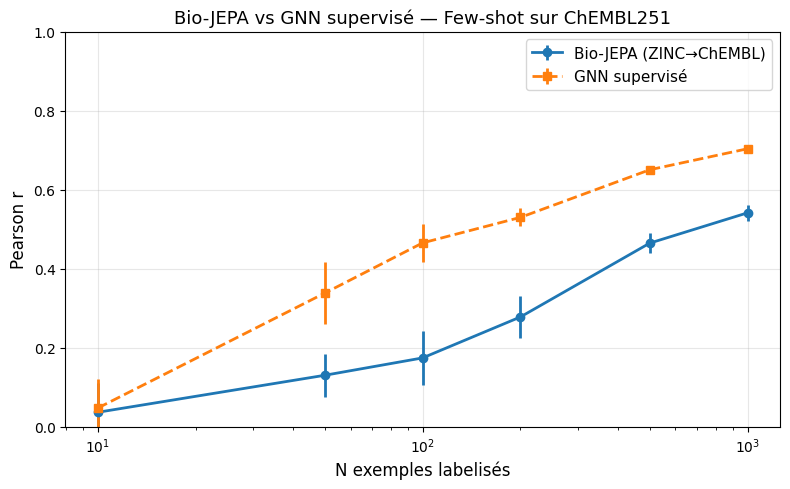

✓ Figure sauvegardée sur Drive


In [11]:
import json
import matplotlib.pyplot as plt

with open('results/few_shot_transfer.json') as f:
    data = json.load(f)

N        = data['N_values']
jepa_r   = [x['mean_r'] for x in data['bio_jepa']]
jepa_std = [x['std_r']  for x in data['bio_jepa']]
gnn_r    = [x['mean_r'] for x in data['gnn_supervise']]
gnn_std  = [x['std_r']  for x in data['gnn_supervise']]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(N, jepa_r, yerr=jepa_std, marker='o', label='Bio-JEPA (ZINC→ChEMBL)', linewidth=2)
ax.errorbar(N, gnn_r,  yerr=gnn_std,  marker='s', label='GNN supervisé', linewidth=2, linestyle='--')
ax.set_xscale('log')
ax.set_xlabel('N exemples labelisés', fontsize=12)
ax.set_ylabel('Pearson r', fontsize=12)
ax.set_title('Bio-JEPA vs GNN supervisé — Few-shot sur ChEMBL251', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('results/few_shot_curve.png', dpi=150)
shutil.copy('results/few_shot_curve.png', f'{DRIVE_SAVE_PATH}/few_shot_curve.png')
plt.show()
print('✓ Figure sauvegardée sur Drive')